In [1]:
from torch.utils.data import DataLoader , random_split
import torchvision.transforms as transforms
from torchvision.transforms import ToTensor
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import torch


In [2]:
transform= transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor()])   

In [3]:
dataset= ImageFolder(root="./data", transform=transform)

In [4]:
dataset

Dataset ImageFolder
    Number of datapoints: 24998
    Root location: ./data
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
           )

In [5]:
dataset.class_to_idx

{'Cat': 0, 'Dog': 1}

In [6]:
gen = torch.Generator().manual_seed(42)

In [7]:
train_size= int(0.8* len(dataset))
test_size= len(dataset) - train_size
train_dataset, test_dataset= random_split(dataset, [train_size, test_size], generator=gen)

In [8]:
train_size

19998

In [9]:
test_size

5000

In [10]:
train_loader=DataLoader(train_dataset , batch_size=64, shuffle=True)
test_loader=DataLoader(test_dataset, batch_size=64, shuffle=False )

In [11]:
train_loader

In [12]:
test_loader

In [17]:
imgs, labels = next(iter(train_loader))

In [18]:
img = imgs[0]

In [21]:
imgs.shape

torch.Size([64, 3, 64, 64])

In [19]:
img.shape

torch.Size([3, 64, 64])

In [13]:
sum = torch.zeros(3) 
square_sum = torch.zeros(3)
batch_count = 0

for imgs, lbls in train_loader:
    batch_count += 1
    sum += imgs.mean(dim=(0, 2, 3))
    square_sum += (imgs ** 2).mean(dim=(0, 2, 3))

mean = sum / batch_count

var = square_sum / batch_count - mean ** 2

std_dev = torch.sqrt(torch.clamp(var, min=0.0))

/opt/homebrew/lib/python3.11/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


In [14]:
mean

tensor([0.4887, 0.4553, 0.4171])

In [15]:
std_dev

tensor([0.2527, 0.2459, 0.2487])

In [23]:
imgs, labels= next(iter(train_loader))

In [24]:
imgs1, labels1= next(iter(train_loader))

In [27]:
if(list(labels)==list(labels1)):
    print("yes")

In [28]:
labels

tensor([1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1,
        0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0,
        1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1])

In [29]:
labels1

tensor([1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0,
        0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1,
        1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1])

/var/folders/j2/9hsk1jq12rjbt8qz1vrdnbth0000gn/T/ipykernel_92775/1107554340.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mean= torch.tensor(mean).cpu().detach()
/var/folders/j2/9hsk1jq12rjbt8qz1vrdnbth0000gn/T/ipykernel_92775/1107554340.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  std_dev= torch.tensor(std_dev).cpu().detach()


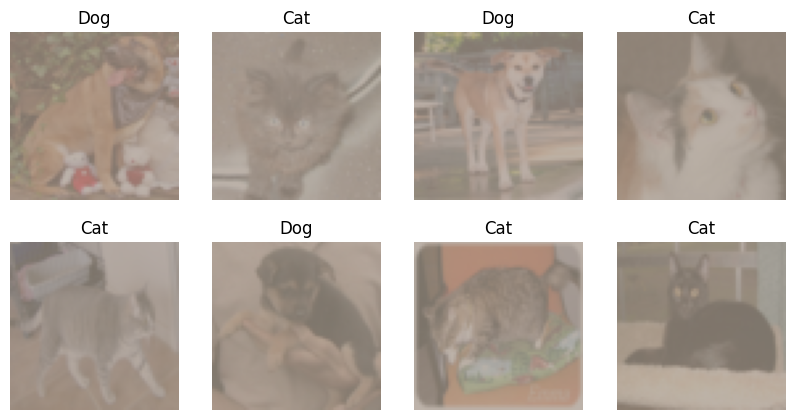

In [30]:

# convert train_loader to iter object and then choose the 1st object
fig, axes= plt.subplots(2,4, figsize=(10,5)) 
# figsize= (w,h)
#  2  row, 4 column
# figure object is the canvas
# axes object is the plotting areas
#In Matplotlib, axes.flat is an iterator that flattens 
# a multi-dimensional array of subplots 
# (axes) into a simple, one-dimensional sequence.

mean= torch.tensor(mean).cpu().detach()
std_dev= torch.tensor(std_dev).cpu().detach()
for i , ax in enumerate(axes.flat):
    img=imgs[i].permute(1,2,0)
    ax.imshow(img*std_dev+mean)
    ax.set_title(dataset.classes[labels[i]])
    ax.axis("off")
plt.show()